In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('employee.csv')
df.head(5)

,EmployeeID,Name,Age,Gender,Department,Experience,Salary,City,Education,Performance,LeftCompany
0,101,Amit,25,Male,IT,2,35000,Pune,BTech,Good,No
1,102,Priya,28,Female,HR,4,45000,Mumbai,MBA,Excellent,No
2,103,Rahul,35,Male,Finance,8,70000,Nashik,MCom,Average,Yes
3,104,Sneha,29,Female,IT,5,52000,Pune,BTech,Good,No
4,105,Karan,42,Male,Sales,15,90000,Mumbai,MBA,Excellent,No


In [3]:
df.tail(5)

,EmployeeID,Name,Age,Gender,Department,Experience,Salary,City,Education,Performance,LeftCompany
10,111,Sachin,45,Male,Management,20,120000,Mumbai,MBA,Excellent,No
11,112,Riya,23,Female,HR,1,30000,Nashik,BBA,Average,Yes
12,113,Ajay,34,Male,IT,7,65000,Pune,BTech,Good,No
13,114,Komal,30,Female,Finance,5,55000,Nagpur,MCom,Good,No
14,115,Deepak,50,Male,Management,25,150000,Mumbai,MBA,Excellent,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   EmployeeID   15 non-null     int64
 1   Name         15 non-null     str  
 2   Age          15 non-null     int64
 3   Gender       15 non-null     str  
 4   Department   15 non-null     str  
 5   Experience   15 non-null     int64
 6   Salary       15 non-null     int64
 7   City         15 non-null     str  
 8   Education    15 non-null     str  
 9   Performance  15 non-null     str  
 10  LeftCompany  15 non-null     str  
dtypes: int64(4), str(7)
memory usage: 1.4 KB


In [5]:
df.describe()

,EmployeeID,Age,Experience,Salary
count,15.000000,15.000000,15.000000,15.000000
mean,108.000000,32.466667,7.600000,64200.000000
std,4.472136,8.122866,7.159409,34172.252737
min,101.000000,23.000000,1.000000,30000.000000
25%,104.500000,26.500000,2.500000,39500.000000
50%,108.000000,30.000000,5.000000,55000.000000
75%,111.500000,36.500000,9.000000,75000.000000
max,115.000000,50.000000,25.000000,150000.000000


In [7]:
df.dtypes

EmployeeID     int64
Name             str
Age            int64
Gender           str
Department       str
Experience     int64
Salary         int64
City             str
Education        str
Performance      str
LeftCompany      str
dtype: object

In [8]:
df.isnull().sum()

EmployeeID     0
Name           0
Age            0
Gender         0
Department     0
Experience     0
Salary         0
City           0
Education      0
Performance    0
LeftCompany    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[df["Salary"]> 50000]

,EmployeeID,Name,Age,Gender,Department,Experience,Salary,City,Education,Performance,LeftCompany
2,103,Rahul,35,Male,Finance,8,70000,Nashik,MCom,Average,Yes
3,104,Sneha,29,Female,IT,5,52000,Pune,BTech,Good,No
4,105,Karan,42,Male,Sales,15,90000,Mumbai,MBA,Excellent,No
6,107,Rohit,31,Male,Finance,6,60000,Pune,MCom,Average,Yes
8,109,Vikas,38,Male,Sales,10,80000,Mumbai,MBA,Excellent,No
10,111,Sachin,45,Male,Management,20,120000,Mumbai,MBA,Excellent,No
12,113,Ajay,34,Male,IT,7,65000,Pune,BTech,Good,No
13,114,Komal,30,Female,Finance,5,55000,Nagpur,MCom,Good,No
14,115,Deepak,50,Male,Management,25,150000,Mumbai,MBA,Excellent,No


In [11]:
df.groupby("Department")["Salary"].mean()

Department
Finance        61666.666667
HR             39333.333333
IT             44000.000000
Management    135000.000000
Sales          85000.000000
Name: Salary, dtype: float64

(array([3., 3., 3., 0., 2., 1., 0., 1., 1., 1.]),
 array([23. , 25.7, 28.4, 31.1, 33.8, 36.5, 39.2, 41.9, 44.6, 47.3, 50. ]),
 <BarContainer object of 10 artists>)

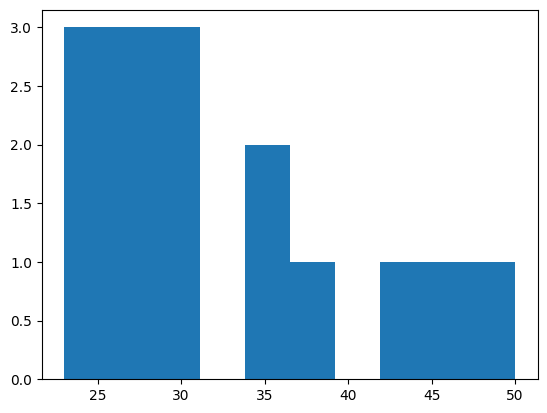

In [13]:
import matplotlib.pyplot as plt
plt.hist(df["Age"])

<Axes: >

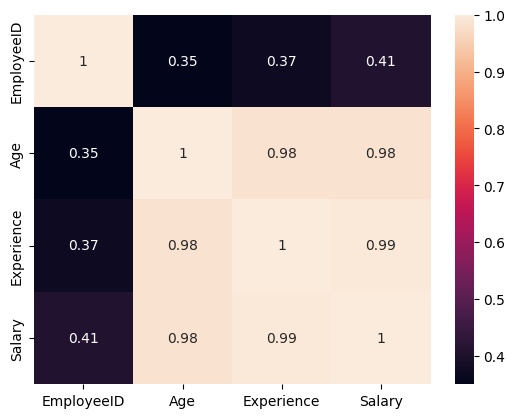

In [16]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True),annot=True)

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df[["Age","Salary"]] = scaler.fit_transform(df[["Age","Salary"]])

In [19]:
from sklearn.model_selection import train_test_split
x = df.drop("Salary",axis=1)
y = df["Salary"]
x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=42)